In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
order=pd.read_csv(r'C:\Users\QC#\Downloads\fact_orders.csv')
resturent=pd.read_csv(r'C:\Users\QC#\Downloads\dim_restaurant.csv')
location=pd.read_csv(r'C:\Users\QC#\Downloads\dim_location.csv')
dishes=pd.read_csv(r'C:\Users\QC#\Downloads\dim_dish.csv')
date=pd.read_csv(r'C:\Users\QC#\Downloads\dim_date.csv')

In [3]:
order

,order_id,date_id,location_id,restaurant_id,food_id,price,rating,rating_count
0,1,1,1,1,1,133.9,4.0,0
1,2,2,2,2,2,52.0,4.5,25
2,3,3,2,2,3,117.0,4.7,48
3,4,4,2,2,4,65.0,4.6,65
4,5,5,2,2,5,130.0,4.0,0
...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0
197426,197427,156,989,993,82888,140.0,4.4,0
197427,197428,57,989,993,82889,126.0,4.4,0
197428,197429,231,989,993,82890,85.0,4.4,0


In [4]:
resturent

,restaurant_id,restaurant_name
0,1,Anand Sweets & Savouries
1,2,Srinidhi Sagar Deluxe
2,3,Thalassery Restaurant
3,4,Appu Donne Biriyani Palace
4,5,Bismillah Taj Hotel
...,...,...
988,989,Valley Vista
989,990,Etho Metho
990,991,Roll Corner
991,992,Hot Stuff Fast Food


In [5]:
location

,location_id,state,city,location
0,1,Karnataka,Bengaluru,Rajarajeshwari Nagar
1,2,Karnataka,Bengaluru,Kengeri
2,3,Karnataka,Bengaluru,Kanmanike Village
3,4,Karnataka,Bengaluru,Bidadi
4,5,Karnataka,Bengaluru,Kengeri Satellite Town
...,...,...,...,...
990,991,Sikkim,Gangtok,Gairigaon
991,992,Sikkim,Gangtok,West Point
992,993,Sikkim,Gangtok,Baluwakhani
993,994,Sikkim,Gangtok,Sikkim Manipal


In [6]:
dishes

,dish_id,category,dish_name
0,1,Snack,Butter Murukku200gm
1,2,Recommended,Badam Milk
2,3,Recommended,Chow Chow Bath
3,4,Recommended,Kesari Bath
4,5,Recommended,Mix Raitha
...,...,...,...
82886,82887,Momos,Soya cheese chilli momo
82887,82888,Momos,Kurkure momo fried
82888,82889,Momos,Chilli cheese momo
82889,82890,Momos,Veg Momos 8 Pc


In [7]:
date

,date_id,order_date
0,1,29-06-25
1,2,03-04-25
2,3,15-01-25
3,4,17-04-25
4,5,13-03-25
...,...,...
238,239,07-03-25
239,240,21-03-25
240,241,02-03-25
241,242,27-03-25


In [8]:
date['order_date']=pd.to_datetime(date['order_date'])

C:\Users\QC#\AppData\Local\Temp\ipykernel_13868\4105683097.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date['order_date']=pd.to_datetime(date['order_date'])


In [9]:
date['Month']=date['order_date'].dt.month

In [10]:
order.rename(columns={'food_id':'dish_id'},inplace=True)

In [11]:
order.duplicated().sum()

np.int64(0)

In [12]:
resturent.duplicated().sum()

np.int64(0)

In [13]:
location.duplicated().sum()

np.int64(0)

In [14]:
dishes.duplicated().sum()

np.int64(0)

In [15]:
date.duplicated().sum()

np.int64(0)

In [16]:
order.isna().sum()

order_id         0
date_id          0
location_id      0
restaurant_id    0
dish_id          0
price            0
rating           0
rating_count     0
dtype: int64

In [17]:
resturent.isna().sum()

restaurant_id      0
restaurant_name    0
dtype: int64

In [18]:
location.isnull().sum()

location_id    0
state          0
city           0
location       0
dtype: int64

In [19]:
dishes.isna().sum()

dish_id      0
category     0
dish_name    0
dtype: int64

In [20]:
date.isnull().sum()

date_id       0
order_date    0
Month         0
dtype: int64

In [21]:
df_resturent_order=pd.merge(order,resturent,on='restaurant_id',how='inner')

In [22]:
df_returent_order_location=pd.merge(df_resturent_order,location,on='location_id',how='inner')

In [23]:
df_returent_order_location_dishes=pd.merge(df_returent_order_location,dishes,on='dish_id',how='inner')

In [24]:
df_final=pd.merge(df_returent_order_location_dishes,date,on='date_id',how='inner')

In [25]:
df_final

,order_id,date_id,location_id,restaurant_id,dish_id,price,rating,rating_count,restaurant_name,state,city,location,category,dish_name,order_date,Month
0,1,1,1,1,1,133.9,4.0,0,Anand Sweets & Savouries,Karnataka,Bengaluru,Rajarajeshwari Nagar,Snack,Butter Murukku200gm,2025-06-29,6
1,2,2,2,2,2,52.0,4.5,25,Srinidhi Sagar Deluxe,Karnataka,Bengaluru,Kengeri,Recommended,Badam Milk,2025-03-04,3
2,3,3,2,2,3,117.0,4.7,48,Srinidhi Sagar Deluxe,Karnataka,Bengaluru,Kengeri,Recommended,Chow Chow Bath,2025-01-15,1
3,4,4,2,2,4,65.0,4.6,65,Srinidhi Sagar Deluxe,Karnataka,Bengaluru,Kengeri,Recommended,Kesari Bath,2025-04-17,4
4,5,5,2,2,5,130.0,4.0,0,Srinidhi Sagar Deluxe,Karnataka,Bengaluru,Kengeri,Recommended,Mix Raitha,2025-03-13,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197425,197426,190,989,993,82887,112.0,4.4,0,Mama's Kitchen,Sikkim,Gangtok,Gangtok,Momos,Soya cheese chilli momo,2025-01-25,1
197426,197427,156,989,993,82888,140.0,4.4,0,Mama's Kitchen,Sikkim,Gangtok,Gangtok,Momos,Kurkure momo fried,2025-02-07,2
197427,197428,57,989,993,82889,126.0,4.4,0,Mama's Kitchen,Sikkim,Gangtok,Gangtok,Momos,Chilli cheese momo,2025-03-25,3
197428,197429,231,989,993,82890,85.0,4.4,0,Mama's Kitchen,Sikkim,Gangtok,Gangtok,Momos,Veg Momos 8 Pc,2025-03-26,3


In [26]:
df_final.isnull().sum()

order_id           0
date_id            0
location_id        0
restaurant_id      0
dish_id            0
price              0
rating             0
rating_count       0
restaurant_name    0
state              0
city               0
location           0
category           0
dish_name          0
order_date         0
Month              0
dtype: int64

In [27]:
df_final.duplicated().sum()

np.int64(0)

In [28]:
df_final.describe()

,order_id,date_id,location_id,restaurant_id,dish_id,price,rating,rating_count,order_date,Month
count,197430.00000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430.000000,197430,197430.000000
mean,98715.50000,121.516092,471.434149,258.741686,22114.367502,268.512920,4.341582,28.321805,2025-05-24 17:18:21.388847,5.295609
min,1.00000,1.000000,1.000000,1.000000,1.000000,0.950000,1.500000,0.000000,2025-01-01 00:00:00,1.000000
25%,49358.25000,61.000000,206.000000,33.000000,2599.000000,139.000000,4.300000,0.000000,2025-03-13 00:00:00,3.000000
50%,98715.50000,122.000000,453.000000,100.000000,10341.500000,229.000000,4.400000,2.000000,2025-05-21 00:00:00,5.000000
75%,148072.75000,182.000000,747.000000,463.000000,37812.750000,329.000000,4.500000,15.000000,2025-07-29 00:00:00,7.000000
max,197430.00000,243.000000,995.000000,993.000000,82891.000000,8000.000000,5.000000,999.000000,2025-12-08 00:00:00,12.000000
std,56993.27616,70.154857,302.904020,292.472935,24259.122654,219.338363,0.422585,87.542593,NaN,2.966273


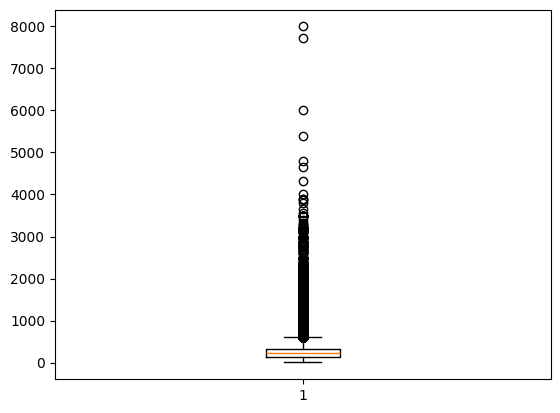

In [29]:
plt.boxplot(x=df_final['price'])
plt.show()

In [49]:
top_expensive=df_final[['category','dish_name','price']].sort_values(by='price',ascending=False).head(20)
print(top_expensive)

                                   category  \
54940                        PARTY SPECIALS   
54943                        PARTY SPECIALS   
54939                        PARTY SPECIALS   
54942                        PARTY SPECIALS   
33890                  Party Menu for 10pax   
134119                               Combos   
134121                               Combos   
54938                        PARTY SPECIALS   
22321    Hyderabadi Dum Biryani pakki Style   
24267          Biryani Buckets super Savers   
135097         Biryani Buckets super Savers   
33891                  Party Menu for 10pax   
24272          Biryani Buckets super Savers   
72098                           Gift Hamper   
72095                           Gift Hamper   
54655   Janmashtami Special Falahari Sweets   
13170             Kids Special  Pizza Party   
27853             Kids Special  Pizza Party   
8640              Kids Special  Pizza Party   
56365             Kids Special  Pizza Party   

            

These Values are not outliers these are party,Gift_pack e.t.c

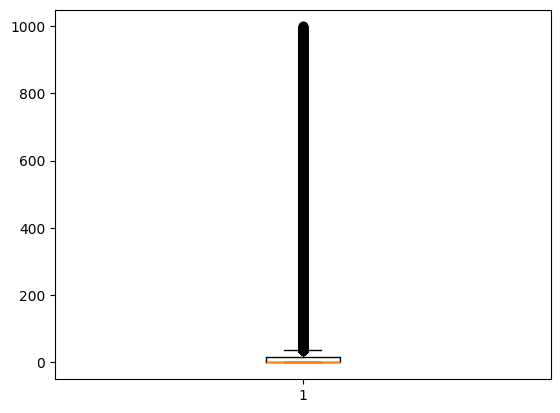

In [31]:
plt.boxplot(x=df_final['rating_count'])
plt.show()

In [32]:
high_rated_orders=df_final[df_final['rating_count']==999]
high_rated_orders

,order_id,date_id,location_id,restaurant_id,dish_id,price,rating,rating_count,restaurant_name,state,city,location,category,dish_name,order_date,Month
130473,130474,103,659,520,46692,130.0,4.6,999,Om Sweets & Snacks,Haryana,Gurgaon,Sector 4,Recommended,Bhalla Papri Chaat,2025-02-02,2
130518,130519,223,659,520,46719,130.0,4.6,999,Om Sweets & Snacks,Haryana,Gurgaon,Sector 4,Chaat,Bhalla Papri Chaat,2025-07-31,7


This is Extreme values not outlier according to Bussiness Context

In [33]:
#Top Resturet by rating
df_final.groupby('restaurant_name')['rating_count'].mean().sort_values(ascending=False).head(10)

restaurant_name
Rahmaniya Kethel's Chicken    394.454545
Ranga Sai Andhra Tiffins      390.072464
M/S Girija Hotel              365.250000
Sri Tiffins                   302.257576
Pizza Jalapenia (Downtown)    300.666667
Devi Fast Food                265.431373
Jugaad Jn                     243.582915
Chiyang                       240.850000
Scholars                      239.937500
Panna Sweets & Restaurant     228.863636
Name: rating_count, dtype: float64

In [34]:
#Top Location By Rating
df_final.groupby('location')['rating_count'].mean().sort_values(ascending=False).head(10)

location
Mal Godown Market       365.250000
Kapra                   302.257576
Bohri Kadal             300.666667
GF 1,2 MAHAVIR TOWER    257.590909
RNT Marg                248.600000
Kacheripadi             240.850000
Jagmohan Nagar          228.742857
Pachalam Junction       220.169014
Bani Park               199.436893
Green Park              199.200000
Name: rating_count, dtype: float64

In [35]:
#Top category by rating
df_final.groupby('category')['rating_count'].mean().sort_values(ascending=False).head(10)

category
Special Quick Lunch Parcel    929.0
Special Meal Parcel           791.0
Kolkata Biryani               713.0
Water& Plate                  688.0
Steam & Fries momos           682.0
Puri                          677.0
Special Kebab Biryani         601.5
Affordable Meal               571.0
Lassi & Raita                 564.0
Bondas                        548.5
Name: rating_count, dtype: float64

In [36]:
#Expensive Category 
df_final.groupby('category')['price'].mean().sort_values(ascending=False).head(10)

category
PARTY SPECIALS                    5520.833333
Party Menu for 10pax              4299.000000
56 Bhog                           2739.000000
Chefs Special Assorted Platter    2552.000000
Celebration Box                   2376.000000
Hampers & Gift Boxes              2270.769231
Family Meal Box serves 4 To 6     2115.666667
Mega Momos Platter                2091.500000
3D Customised Cake                2089.000000
Biryani Bucket Serves 46          2049.000000
Name: price, dtype: float64

In [37]:
#Expensive Dishes
df_final.groupby('dish_name')['price'].mean().sort_values(ascending=False).head(20)

dish_name
Choley Bhature Classic Combo for 20                         8000.0
Special Deluxe Thali Feast for 15                           7725.0
Choley Bhature Classic Combo for 15                         6000.0
Special Deluxe Thali Feast for 10                           5400.0
Party Menu Plan I                                           4799.0
T20 Thunder Combo Serves 12 Non Veg                         4652.0
Trophy Celebration Combo Serves 12 Veg                      4328.0
Choley Bhature Classic Combo for 10                         4000.0
Mutton Standard Pack                                        3900.0
Thalappakatti Naidu Mutton Biryani Party Bucket 910pax      3884.0
Party Menu Plan II                                          3799.0
Utsaah set Of 4 Jar                                         3570.0
Luxury Au Gold Gift Hamper                                  3500.0
Chhapan Bhog Prasad Thali                                   3500.0
Kids Birthday Chocolate Cake with Pizza Party pack o

In [38]:
#correllation
df_final[['price','rating','rating_count']].corr()

,price,rating,rating_count
price,1.000000,0.029369,-0.101235
rating,0.029369,1.000000,0.016156
rating_count,-0.101235,0.016156,1.000000


No relationship b/w price and rating (people give both cheap and expensive dishes 5 star Rating)

In [39]:
#Raking dishes of each category based on rating count
df_final['dish_rank']=df_final.groupby('category')['rating_count'].rank(ascending=False,method='first')
#Top 3 dishes per category
top_dishes=df_final[df_final['dish_rank']<=3].copy()
result=top_dishes[['category','dish_name','price','dish_rank']]
print(result.sort_values(by=['category','dish_rank']))

                   category                      dish_name  price  dish_rank
101260              Chinese            Honey Chilli Patato  150.0        1.0
101262              Chinese                  Hakka Noodles  120.0        2.0
101264              Chinese                Stem Momos 6pcs   75.0        3.0
108446     Desi Ghee Sweets                Motichoor Ladoo  450.0        1.0
108440     Desi Ghee Sweets           Elaichi Mathura Peda  680.0        2.0
...                     ...                            ...    ...        ...
90287            cham cham                 Kheer Cham Cham  120.0        1.0
90289            cham cham                 Baked Cham Cham  175.0        2.0
90294            cham cham                      Malai chop  120.0        3.0
197291  make your own combo               Combo Of Noodles  155.0        1.0
148465                 nota  Chicken Chilli Momos 6 Pieces  310.0        1.0

[13785 rows x 4 columns]


In [40]:
#Time series Analysis
month_sales=df_final.groupby('Month')['price'].sum().reset_index()

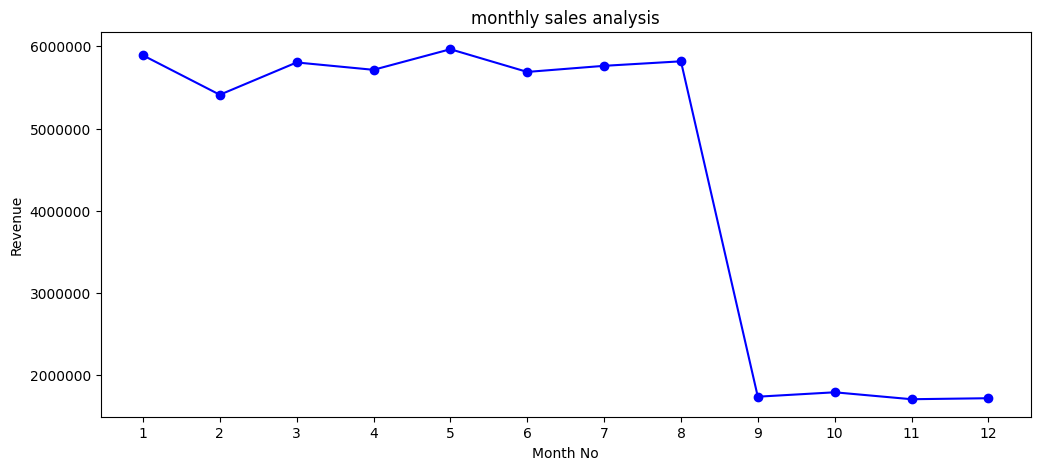

In [41]:
month_sales=month_sales.sort_values('Month')
plt.figure(figsize=(12,5))
plt.plot(month_sales['Month'],month_sales['price'],marker='o',linestyle='-',color='b')
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(month_sales['Month'])
plt.title('monthly sales analysis')
plt.xlabel('Month No')
plt.ylabel('Revenue')
plt.show()

In [42]:
engine=create_engine('postgresql://'(own path)

In [43]:
order.to_sql('fct_orders',con=engine,if_exists='replace',index=False)

430

In [44]:
resturent.to_sql('dim_restuarant',con=engine,if_exists='replace',index=False)

993

In [45]:
location.to_sql('dim_location',con=engine,if_exists='replace',index=False)
dishes.to_sql('dim_dish',con=engine,if_exists='replace',index=False)
date.to_sql('dim_date',con=engine,if_exists='replace',index=False)

243

In [46]:
order.to_csv('fct_orders.csv',index=False)
resturent.to_csv('dim_restuarant.csv',index=False)
location.to_csv('dim_location.csv',index=False)
dishes.to_csv('dim_dish.csv',index=False)
date.to_csv('dim_date.csv',index=False)